In [1]:
# core
import os
import numpy as np
import pandas as pd

# modeling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, cross_val_score

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# plots
import matplotlib.pyplot as plt

# utils
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# path to your training data
data_path = "./data/train_mp.csv"  # change if needed
df = pd.read_csv(data_path)

# columns to exclude from features (as requested)
non_feature_cols = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# feature columns = all except the excluded ones (then keep only numeric)
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# label
target_col = "formation_energy_per_atom"
y_all = df[target_col].astype(float).copy()

# basic checks
print("n_samples:", len(df))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])
X_all.head()


n_samples: 6419
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


,H,He,Li,Be,B,C,N,O,F,Ne,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.0,0,0.0,0,0.0,0.750000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,229.0,35.0,202.750000,13.125000,194.0
1,0.0,0,0.0,0,0.0,0.200000,0.0,0.0,0.0,0,...,2.110663,1.68853,0.675412,2.110663,194.0,229.0,35.0,222.000000,11.200000,229.0
2,0.0,0,0.0,0,0.0,0.558824,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
3,0.0,0,0.0,0,0.0,0.600000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
4,0.0,0,0.0,0,0.0,0.555556,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,225.0,31.0,207.777778,15.308642,194.0


In [3]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
)

# simple imputation (median) to handle any missing values
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))  # use train medians

print("train shape:", X_train.shape, "| test shape:", X_test.shape)


train shape: (5135, 250) | test shape: (1284, 250)


In [4]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# a reasonable, compact grid (adjust as needed)
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# optimize for RMSE; return other scores for inspection
gscv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gscv.fit(X_train, y_train)
best_rf = gscv.best_estimator_
print("best params:", gscv.best_params_)
print("best cv RMSE:", -gscv.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
best params: {'bootstrap': True, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 600}
best cv RMSE: 0.37414866606261327


In [5]:
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def eval_regression(y_true, y_pred, label=""):
    # ensure 1D arrays
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    # robust RMSE for all sklearn versions
    mse  = mean_squared_error(y_true, y_pred)   # default returns MSE
    rmse = sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f}")
    return rmse, mae, r2

# predictions
yhat_tr = best_rf.predict(X_train)
yhat_te = best_rf.predict(X_test)

print("== training ==")
tr_metrics = eval_regression(y_train, yhat_tr, "train")

print("\n== test ==")
te_metrics = eval_regression(y_test, yhat_te, "test")


== training ==
train RMSE: 0.28 | MAE: 0.11 | R2: 0.90

== test ==
test RMSE: 0.43 | MAE: 0.21 | R2: 0.79


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# RMSE (fallback-safe)
try:
    cv_rmse = -cross_val_score(best_rf, X_all, y_all, cv=cv,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
except ValueError:
    mse_scores = -cross_val_score(best_rf, X_all, y_all, cv=cv,
                                  scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.sqrt(mse_scores)

cv_mae  = -cross_val_score(best_rf, X_all, y_all, cv=cv,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
cv_r2   =  cross_val_score(best_rf, X_all, y_all, cv=cv, scoring="r2", n_jobs=-1)

print(f"cv RMSE: mean={cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"cv MAE : mean={cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"cv R2  : mean={cv_r2.mean():.2f} ± {cv_r2.std():.2f}")

yhat_cv = cross_val_predict(best_rf, X_all, y_all, cv=cv, n_jobs=-1)


cv RMSE: mean=0.38 ± 0.03
cv MAE : mean=0.19 ± 0.01
cv R2  : mean=0.82 ± 0.02


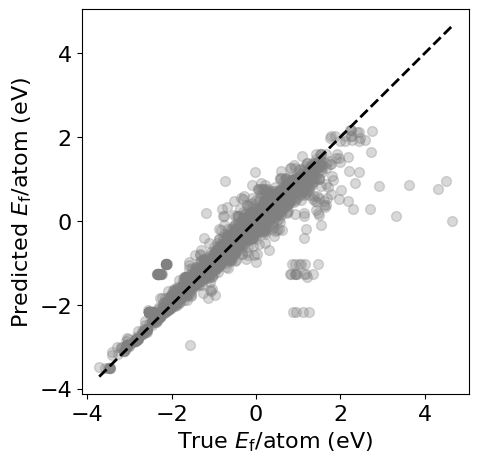

In [7]:
plt.figure(figsize=(5,5))
plt.scatter(
    y_train, yhat_tr,
    s=50, alpha=0.3,
    c="grey"  # scatter color
)

lims = [min(y_train.min(), yhat_tr.min()), max(y_train.max(), yhat_tr.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="black",
    linestyle="--"  # dashed line
)

# use consistent notation: E_f/atom
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig_s1a.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


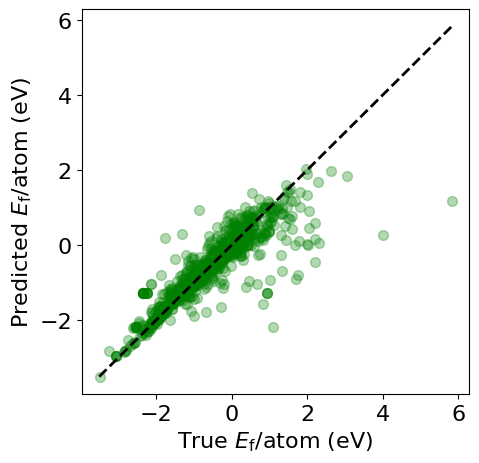

In [8]:
plt.figure(figsize=(5,5))
plt.scatter(
    y_test, yhat_te,
    s=50, alpha=0.3,
    c="green"  # scatter color for test set
)

lims = [min(y_test.min(), yhat_te.min()), max(y_test.max(), yhat_te.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="black",
    linestyle="--"  # dashed line
)

# use consistent notation: E_f/atom
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig2a.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


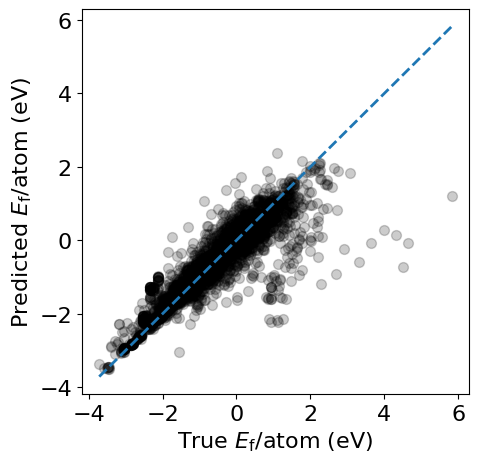

In [13]:
plt.figure(figsize=(5,5))
plt.scatter(
    y_all, yhat_cv,
    s=50, alpha=0.2,
    c="black"  # scatter color for cv set
)

lims = [min(y_all.min(), yhat_cv.min()), max(y_all.max(), yhat_cv.max())]
plt.plot(
    lims, lims,
    linewidth=2,
    color="tab:blue",
    linestyle="--"  # dashed line
)

# use consistent notation: E_f/atom
plt.xlabel(r"True $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.ylabel(r"Predicted $E_\mathrm{f}$/atom (eV)", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.savefig('./visual/fig_s1b.jpg', format='jpg', dpi=500, bbox_inches='tight')
plt.show()


In [ ]:
# import seaborn as sns
# import numpy as np

# # rebuild feature importance series (native RF importance)
# importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)

# # get top 10
# imp_top = importances.sort_values(ascending=False).head(10)

# # map original feature names → Feature #XXX
# feature_map = {
#     feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
#     for feat in imp_top.index
# }

# # relabel for plotting
# imp_top_short = imp_top.rename(index=feature_map)

# plt.figure(figsize=(5,5))
# sns.barplot(
#     x=imp_top_short.values,
#     y=imp_top_short.index,
#     palette="viridis"
# )

# plt.xlabel("Importance", fontsize=16)
# plt.ylabel("Feature", fontsize=16)

# # set xticks at 0.00, 0.05, 0.10, 0.15 …
# max_val = imp_top_short.max()
# plt.xticks(
#     np.arange(0, max_val + 0.05, 0.05),
#     fontsize=16
# )
# plt.yticks(fontsize=16)

# plt.savefig('./visual/fig2d.jpg', format='jpg', dpi=500, bbox_inches='tight')
# plt.show()

# # lookup table for reference
# lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
# display(lookup)



In [ ]:
# # path to your new feature-only csv
# new_features_path = "/mnt/data/new_features.csv"   # change to your file
# out_path = "/mnt/data/predictions.csv"             # where to save

# new_df = pd.read_csv(new_features_path)

# # ensure same columns & order as training
# missing = set(X_train.columns) - set(new_df.columns)
# extra   = set(new_df.columns) - set(X_train.columns)

# if missing:
#     raise ValueError(f"the following required feature columns are missing in the input: {sorted(missing)[:10]} ...")
# # reorder and drop extras
# X_new = new_df.reindex(columns=X_train.columns, fill_value=np.nan)

# # impute using train medians
# X_new = X_new.fillna(X_train.median(numeric_only=True))

# # predict
# pred = best_rf.predict(X_new)

# # write out
# pred_df = new_df.copy()
# pred_df["predicted_formation_energy_per_atom"] = pred
# pred_df.to_csv(out_path, index=False)
# print(f"saved predictions to: {out_path}")
# pred_df.head()
